# **Import Everything**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import floor
import matplotlib.ticker as mtick
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
print('Everything is Imported Boss')

Everything is Imported Boss


# **Data exploration**

## **Load the Data**

In [2]:
file_path = input("Enter the File Path Baby: ")
df = pd.read_csv(file_path)
print('Data Loaded Baby')

Data Loaded Baby


## **Exploration**

In [3]:
print(f'The dataset have {df.shape[0]} Rows and {df.shape[1]} columns with {df.duplicated().sum()} Duplicates')

The dataset have 30300 Rows and 10 columns with 297 Duplicates


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30300 entries, 0 to 30299
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   batting_avg          29692 non-null  str    
 1   strike_rate          29694 non-null  float64
 2   centuries            29691 non-null  float64
 3   half_centuries       29694 non-null  float64
 4   fours_per_innings    29696 non-null  float64
 5   sixes_per_innings    29690 non-null  float64
 6   bowling_avg          29696 non-null  float64
 7   economy_rate         29694 non-null  float64
 8   wickets              29695 non-null  float64
 9   fielding_dismissals  29693 non-null  float64
dtypes: float64(9), str(1)
memory usage: 2.5 MB


In [5]:
df.sample(10)

,batting_avg,strike_rate,centuries,half_centuries,fours_per_innings,sixes_per_innings,bowling_avg,economy_rate,wickets,fielding_dismissals
15205,61.55,108.97,10.12,13.56,7.31,1.60,56.53,8.59,2.39,12.85
11130,59.08,124.20,10.03,24.30,7.92,1.69,81.33,8.53,2.17,14.47
29119,13.97,74.42,0.78,4.28,2.79,0.41,28.93,6.35,75.90,7.25
26364,12.41,83.36,0.26,1.35,2.51,0.56,22.70,NaN,92.36,12.88
26066,9.07,90.86,0.28,3.01,3.45,0.33,20.18,5.87,81.07,9.55
8808,44.13,122.34,9.91,12.57,7.91,1.18,59.01,6.79,0.00,14.24
7435,30.72,148.05,1.36,15.99,4.89,2.93,44.44,9.22,9.04,7.82
5676,39.89,159.48,3.23,7.33,3.37,3.78,43.68,8.99,7.06,5.61
20656,41.64,144.19,3.93,14.10,7.27,4.78,29.51,7.32,53.42,17.66
18872,32.83,122.87,2.24,12.73,7.96,2.70,32.25,7.59,44.14,NaN


In [6]:
df.describe()

,strike_rate,centuries,half_centuries,fours_per_innings,sixes_per_innings,bowling_avg,economy_rate,wickets,fielding_dismissals
count,29694.000000,29691.000000,29694.000000,29696.000000,29690.000000,29696.000000,29694.000000,29695.000000,29693.000000
mean,123.613654,3.668969,13.279822,6.071147,2.036164,45.441858,7.797468,32.182728,11.880722
std,27.614201,3.209574,7.844082,2.313599,1.555541,20.552688,1.523575,34.284398,4.815924
min,48.290000,-3.000000,0.000000,-1.350000,-0.000000,8.890000,-2.000000,-5.000000,-1.540000
25%,106.542500,0.780000,7.250000,4.250000,0.700000,26.080000,6.660000,2.830000,8.320000
50%,124.670000,2.860000,14.045000,6.330000,1.590000,45.290000,7.670000,7.290000,10.930000
75%,143.760000,5.920000,18.970000,7.790000,3.230000,62.750000,8.880000,56.270000,14.710000
max,500.000000,15.500000,37.040000,13.640000,7.830000,109.400000,13.260000,134.370000,31.580000


In [7]:
df.isna().sum()

batting_avg            608
strike_rate            606
centuries              609
half_centuries         606
fours_per_innings      604
sixes_per_innings      610
bowling_avg            604
economy_rate           606
wickets                605
fielding_dismissals    607
dtype: int64

# **Data Cleaning**

## **Create Copy**

In [8]:
df_copy = df.copy()
print('Copy created Baby')

Copy created Baby


## **DataType**

In [9]:
df_copy['batting_avg'] = df_copy['batting_avg'].replace('_err','',regex=True).astype('float')

## **Impossible Values**

In [10]:
Columns = ['batting_avg',
           'centuries',
           'half_centuries',
           'fours_per_innings',
           'sixes_per_innings',
           'economy_rate',
           'wickets',
           'fielding_dismissals']
for col in Columns:
    df_copy.loc[df_copy[col]<0,col] = np.nan
    
print('values Removed Baby')

values Removed Baby


## **Outliers**

In [11]:
columns = df_copy.columns.tolist()

for col in columns:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_copy.loc[df_copy[col] < lower, col] = np.nan
    df_copy.loc[df_copy[col] > upper, col] = np.nan

print("Outliers Handled ✅")

Outliers Handled ✅


## **Duplicates**

In [12]:
print("Dateset have duplicates: ")
print(f"Before: {df_copy.duplicated().sum()}")
df_copy.drop_duplicates(inplace=True)
print(f"After: {df_copy.duplicated().sum()}")

Dateset have duplicates: 
Before: 300
After: 0


## **NaN Values**

In [13]:
print("NaN values in the Dataset is: ")
print(df_copy.isna().sum())
Round = df_copy.columns.tolist()
for col in Round:
    df_copy[col] = df_copy[col].fillna(round(df_copy[col].median(),2))
    
print("\nNaN values in the Dataset After Cleaning is: ")
print(df_copy.isna().sum())

NaN values in the Dataset is: 
batting_avg             605
strike_rate             606
centuries               621
half_centuries          601
fours_per_innings       613
sixes_per_innings       608
bowling_avg             600
economy_rate            633
wickets                 605
fielding_dismissals    1005
dtype: int64

NaN values in the Dataset After Cleaning is: 
batting_avg            0
strike_rate            0
centuries              0
half_centuries         0
fours_per_innings      0
sixes_per_innings      0
bowling_avg            0
economy_rate           0
wickets                0
fielding_dismissals    0
dtype: int64


# **Model**

## **Data preperation**

In [14]:
features = df_copy.columns.tolist()
X = df_copy[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled,columns=X.columns)
X_scaled.describe().round(2)

,batting_avg,strike_rate,centuries,half_centuries,fours_per_innings,sixes_per_innings,bowling_avg,economy_rate,wickets,fielding_dismissals
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,0.00,0.00,-0.00,0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.48,-2.68,-1.15,-1.71,-2.63,-1.32,-1.80,-2.88,-0.93,-2.61
25%,-0.68,-0.60,-0.89,-0.72,-0.77,-0.86,-0.94,-0.74,-0.84,-0.73
50%,0.03,0.04,-0.25,0.10,0.11,-0.28,-0.01,-0.08,-0.71,-0.18
75%,0.72,0.73,0.68,0.71,0.73,0.76,0.83,0.71,0.69,0.60
max,2.91,2.77,3.14,2.96,3.03,3.23,3.14,2.95,3.01,2.83


## **Optimal K**

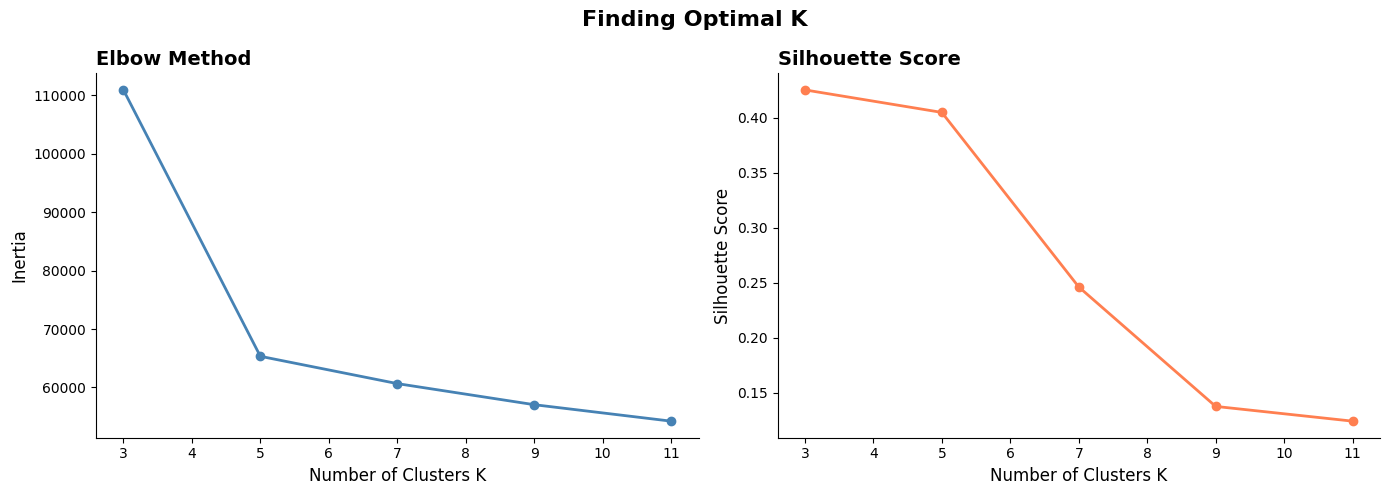

In [16]:
inertias = []
sil_scores = []
K_range = range(3, 12,2)

for k in K_range:
    km = KMeans(n_clusters=k,n_init=10,random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled,km.labels_))
    
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_xlabel('Number of Clusters K', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method', fontweight='bold', fontsize=14, loc='left')
axes[0].spines[['right','top']].set_visible(False)

axes[1].plot(K_range, sil_scores, marker='o', color='coral', linewidth=2)
axes[1].set_xlabel('Number of Clusters K', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score', fontweight='bold', fontsize=14, loc='left')
axes[1].spines[['right','top']].set_visible(False)

plt.suptitle('Finding Optimal K', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## **Train**

In [17]:
optimal_k = 5
model = KMeans(n_clusters=optimal_k,random_state=42,n_init=10)
model.fit(X_scaled)
print(f"Model trained with K={optimal_k} ✅")

Model trained with K=5 ✅


## **labels**

In [18]:
# Add cluster labels back to original dataframe
df_copy['cluster'] = model.labels_

# How many rows in each cluster
print(df_copy['cluster'].value_counts().sort_index())

cluster
0    2930
1    6999
2    7991
3    7987
4    4093
Name: count, dtype: int64


## **Labels Summery**

In [19]:
cluster_profile = df_copy.groupby('cluster')[X.columns].mean().round(2)
cluster_profile

,batting_avg,strike_rate,centuries,half_centuries,fours_per_innings,sixes_per_innings,bowling_avg,economy_rate,wickets,fielding_dismissals
cluster,,,,,,,,,,
0,38.13,131.91,4.00,16.02,7.04,2.48,30.27,7.20,44.07,13.27
1,15.37,85.87,0.33,2.23,3.08,0.53,22.49,6.23,83.34,9.98
2,32.04,154.64,2.04,12.00,6.03,3.95,54.69,9.46,5.03,8.06
3,51.69,118.29,7.90,21.90,7.96,1.01,69.64,8.00,2.12,11.97
4,37.97,131.78,3.93,15.98,6.95,2.49,30.31,7.23,44.14,19.81


## **Chart**

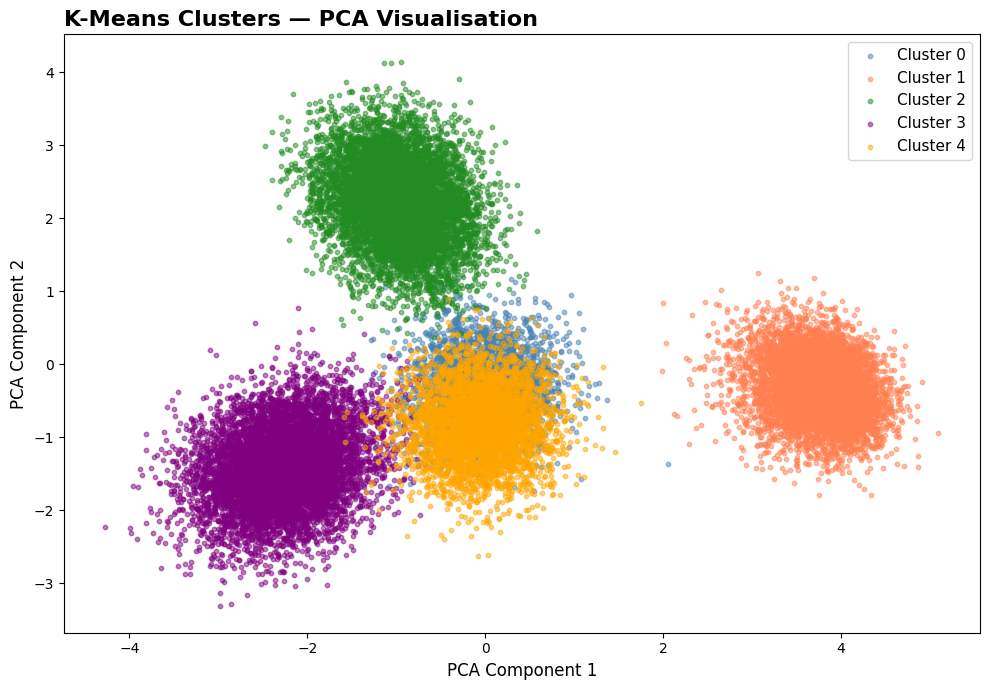

In [20]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
colors = ['steelblue', 'coral', 'forestgreen', 'purple', 'orange']

for cluster_id in range(optimal_k):
    mask = model.labels_ == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[cluster_id], label=f'Cluster {cluster_id}',
                alpha=0.5, s=10)

plt.xlabel('PCA Component 1', fontsize=12)
plt.ylabel('PCA Component 2', fontsize=12)
plt.title('K-Means Clusters — PCA Visualisation',
          fontweight='bold', fontsize=16, loc='left')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

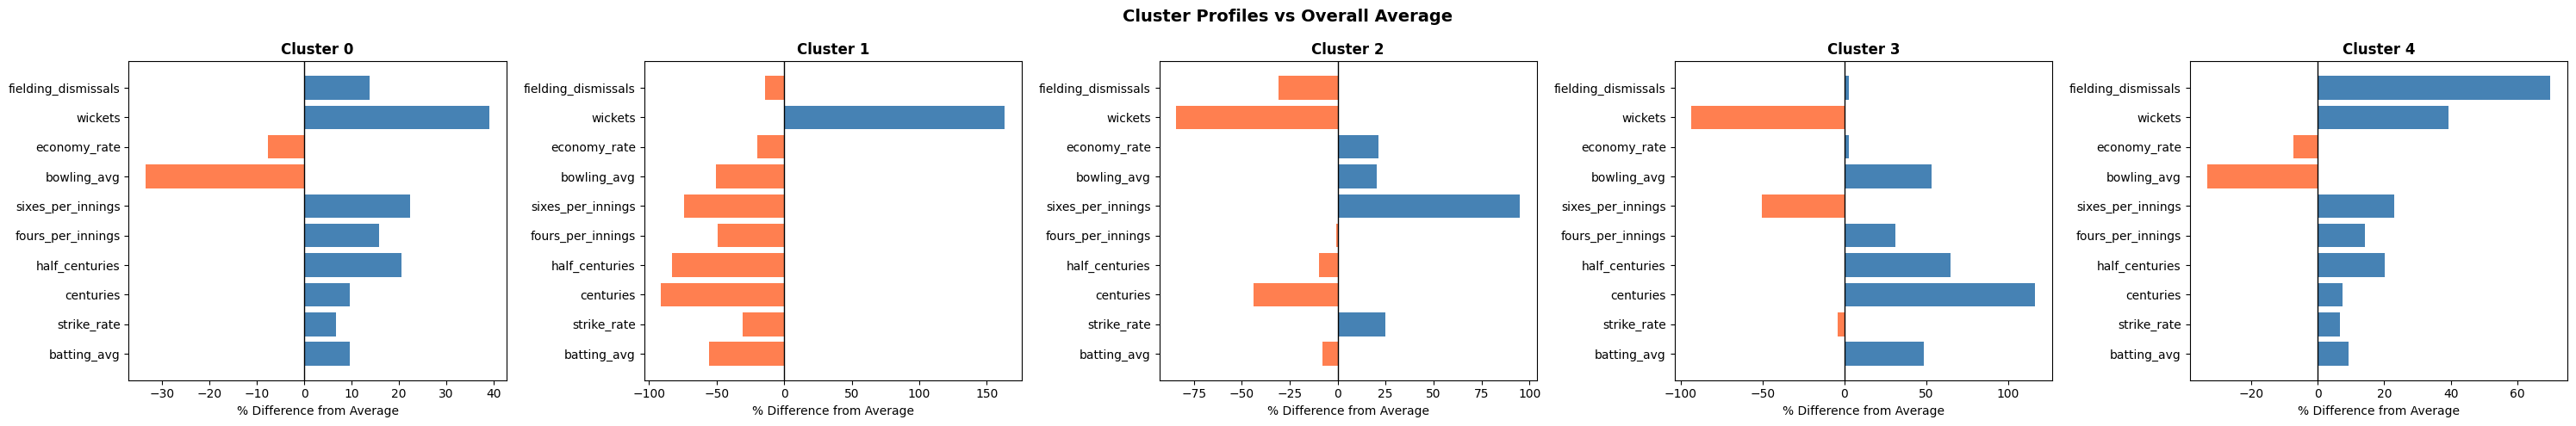

In [21]:
fig, axes = plt.subplots(1, optimal_k, figsize=(6*optimal_k, 5))

for i, ax in enumerate(axes):
    cluster_means = df_copy[df_copy['cluster']==i][X.columns].mean()
    overall_means = df_copy[X.columns].mean()
    diff = ((cluster_means - overall_means) / overall_means * 100).round(1)
    
    colors = ['coral' if v < 0 else 'steelblue' for v in diff]
    ax.barh(diff.index, diff.values, color=colors)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(f'Cluster {i}', fontweight='bold')
    ax.set_xlabel('% Difference from Average')

plt.suptitle('Cluster Profiles vs Overall Average',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()